<a href="https://colab.research.google.com/github/frc383/2-adic-collatz-flow/blob/main/Computational_Bounds_and_Rational_Isomorphisms_in_the_2_Adic_Collatz_Flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from fractions import Fraction
from typing import Union

def get_v2(n: Union[int, Fraction]) -> int:
    """
    Calculates the strict 2-adic valuation for integers and dyadic rationals.
    Utilizes two's complement bitwise logic for O(1) extraction (See Manuscript Section 7.1).
    """
    if n == 0:
        return 0
    if isinstance(n, Fraction):
        return get_v2(n.numerator) - get_v2(n.denominator)
    return (n & -n).bit_length() - 1

def A(n: Union[int, Fraction]) -> Union[int, Fraction]:
    """
    The lifted operator A(n) = 3n + 2^{v_2(n)}.
    Re-indexes the trajectory to track the accumulating 2-adic valuation (See Eq. 1).
    """
    v2 = get_v2(n)
    # Prevent IEEE 754 float degradation by enforcing Fraction on negative powers of 2
    adder = Fraction(2) ** v2 if v2 < 0 else 2 ** v2
    res = 3 * n + adder

    # Dynamically cast back to int if the denominator clears to 1
    if isinstance(res, Fraction) and res.denominator == 1:
        return res.numerator
    return res

def phi(n: Union[int, Fraction]) -> Union[int, Fraction]:
    """
    The Odd Kernel operator.
    Strips away the 2-adic valuation to project back to the odd lattice (See Def. 2.4).
    """
    v2 = get_v2(n)
    divisor = Fraction(2) ** v2 if v2 < 0 else 2 ** v2

    # Use exact rational division or integer division
    res = n / divisor if isinstance(n, Fraction) else n // divisor

    if isinstance(res, Fraction) and res.denominator == 1:
        return res.numerator
    return res

def Table_1():
    """
    Generates the Full Trace of Rational Orbits under A(q) Mirroring Integer T_d Dynamics.
    Demonstrates the exact scaling relationship and cycle detection (Corresponds to Table 1).
    """
    seeds = [Fraction(5, 7), Fraction(8, 65), Fraction(7, 8)]

    print(f"{'Step (i)':<10} | {'Rational State q_i':<20} | {'Integer Num. a_i':<20} | {'Odd Kernel phi(q_i)':<20} | {'d_odd'}")
    print("-" * 95)

    for q in seeds:
        # Extract the odd kernel of the denominator (d_odd)
        d_odd = q.denominator // (2 ** get_v2(q.denominator))
        print(f"Family: d_odd = {d_odd}")

        current_q = q
        history = set()

        for i in range(15):
            # Handle both Fraction and dynamically cast integer states
            a_i = current_q.numerator if isinstance(current_q, Fraction) else current_q
            kernel = phi(current_q)

            # Formatting the cycle collapse/detection string
            kernel_str = f"{kernel.numerator}/{kernel.denominator}" if isinstance(kernel, Fraction) else str(int(kernel))

            if kernel in history:
                kernel_str += " (Cycle)"
                print(f"{i:<10} | {str(current_q):<20} | {a_i:<20} | {kernel_str:<20} | {d_odd}")
                break
            if kernel == 1:
                kernel_str += " (Collapsed)"
                print(f"{i:<10} | {str(current_q):<20} | {a_i:<20} | {kernel_str:<20} | {d_odd}")
                break

            history.add(kernel)
            print(f"{i:<10} | {str(current_q):<20} | {a_i:<20} | {kernel_str:<20} | {d_odd}")
            current_q = A(current_q)
        print("-" * 95)

if __name__ == "__main__":
    Table_1()

Step (i)   | Rational State q_i   | Integer Num. a_i     | Odd Kernel phi(q_i)  | d_odd
-----------------------------------------------------------------------------------------------
Family: d_odd = 7
0          | 5/7                  | 5                    | 5/7                  | 7
1          | 22/7                 | 22                   | 11/7                 | 7
2          | 80/7                 | 80                   | 5/7 (Cycle)          | 7
-----------------------------------------------------------------------------------------------
Family: d_odd = 65
0          | 8/65                 | 8                    | 1/65                 | 65
1          | 544/65               | 544                  | 17/65                | 65
2          | 3712/65              | 3712                 | 29/65                | 65
3          | 19456/65             | 19456                | 19/65                | 65
4          | 124928/65            | 124928               | 61/65                | 65
5     

In [ ]:
import math
from typing import List, Dict, Any

def Table_2():
    """
    Generates the Parity Overhead and Solution Interval Density for Selected Trajectories.
    Classifies seeds based on the path-dependent algebraic obstruction (Corresponds to Table 2).
    """
    header = f"{'Seed (n)':<15} | {'L':<4} | {'S_min':<6} | {'S_obs':<6} | {'Overhead':<10} | {'Density (Dn)':<15} | {'Classification'}"
    print(header)
    print("-" * len(header))

    # Seed data utilizing values established in Section 5.2
    calibrated_seeds: List[Dict[str, Any]] = [
        {"n": "1/3", "L": 1, "s_obs": 2, "type": "Rational"},
        {"n": "13/11", "L": 1, "s_obs": 2, "type": "Rational"},
        {"n": "19/5", "L": 3, "s_obs": 5, "type": "Rational"},
        {"n": "31/32", "L": 39, "s_obs": 67, "type": "Decay"},
        {"n": 3, "L": 5, "s_obs": 8, "type": "Decay"},
        {"n": 7, "L": 11, "s_obs": 20, "type": "Decay"},
        {"n": 27, "L": 41, "s_obs": 70, "type": "Decay"},
        {"n": 31, "L": 39, "s_obs": 67, "type": "Decay"},
        {"n": 31948311, "L": 111, "s_obs": 189, "type": "Decay"},
        {"n": "2^45 - 1", "L": 386, "s_obs": 615, "type": "Decay"}
    ]

    for data in calibrated_seeds:
        n, L, s_obs = data["n"], data["L"], data["s_obs"]

        # S_min = ceil(L * log2(3)): The Diophantine Minimum
        # Represents the baseline irrationality measure (See Section 5.1)
        s_min = math.ceil(L * math.log2(3))
        delta_s = s_obs - s_min

        # Dn = 3^L / (2^S - 3^L): Solution Interval/Density
        # Quantifies the algebraic gap vs noise (See Eq. 5)
        gap = (2**s_obs) - (3**L)

        if gap > 0:
            dn = (3**L) / gap
        else:
            dn = 0.0

        # Classification Logic: Path-Dependent Obstruction Calibration (See Section 5.2)
        if data.get("type") == "Rational":
            classification = "Rational Cycle"
        elif dn < 1 and dn > 0:
            classification = "Observed Decay (Dn << 1)"
        elif dn >= 1:
            classification = "Potential Loop"
        else:
            classification = "Indeterminate"

        # Format Dn in scientific notation for high-precision visibility
        dn_str = f"{dn:.3e}" if dn > 0 else "N/A"

        print(f"{str(n):<15} | {L:<4} | {s_min:<6} | {s_obs:<6} | {delta_s:<10} | {dn_str:<15} | {classification}")

if __name__ == "__main__":
    Table_2()

Seed (n)        | L    | S_min  | S_obs  | Overhead   | Density (Dn)    | Classification
----------------------------------------------------------------------------------------
1/3             | 1    | 2      | 2      | 0          | 3.000e+00       | Rational Cycle
13/11           | 1    | 2      | 2      | 0          | 3.000e+00       | Rational Cycle
19/5            | 3    | 5      | 5      | 0          | 5.400e+00       | Rational Cycle
31/32           | 39   | 62     | 67     | 5          | 2.824e-02       | Observed Decay (Dn << 1)
3               | 5    | 8      | 8      | 0          | 1.869e+01       | Potential Loop
7               | 11   | 18     | 20     | 2          | 2.033e-01       | Observed Decay (Dn << 1)
27              | 41   | 65     | 70     | 5          | 3.188e-02       | Observed Decay (Dn << 1)
31              | 39   | 62     | 67     | 5          | 2.824e-02       | Observed Decay (Dn << 1)
31948311        | 111  | 176    | 189    | 13         | 1.164e-04     

In [ ]:
import math

def Table_3():
    """
    Generates the Target Mapping: Resonant Lengths and their Expansion Polynomials (P_g).
    Demonstrates the exact scaling factor into the generalized operator (Corresponds to Table 3).
    """
    header = f"{'L':<4} | {'S':<4} | {'g':<4} | {'Gap G = 2^S - 3^L':<20} | {'Factorization (G_prim x P_g)':<30} | {'Target Operator'}"
    print(header)
    print("-" * len(header))

    # The resonant path lengths observed in the geometric analysis
    pairs = [(1, 3), (2, 4), (3, 5), (6, 10), (9, 15), (10, 16), (15, 25)]

    for L, S in pairs:
        g = math.gcd(L, S)

        # Calculate the geometric gap G (See Manuscript Section 6, Eq. 6)
        gap = (2**S) - (3**L)

        # Calculate the primitive gap component (G_prim)
        g_prim = (2**(S//g)) - (3**(L//g))

        # Calculate the Expansion Polynomial (P_g)
        p_g = gap // g_prim

        # String formatting matching Table 3 for publication readiness
        fact_str = f"{g_prim} x {p_g:,}"
        target_op = f"T_{p_g:,}"
        gap_str = f"{gap:,}"

        print(f"{L:<4} | {S:<4} | {g:<4} | {gap_str:<20} | {fact_str:<30} | {target_op}")

if __name__ == "__main__":
    Table_3()

L    | S    | g    | Gap G = 2^S - 3^L    | Factorization (G_prim x P_g)   | Target Operator
--------------------------------------------------------------------------------------------
1    | 3    | 1    | 5                    | 5 x 1                          | T_1
2    | 4    | 2    | 7                    | 1 x 7                          | T_7
3    | 5    | 1    | 5                    | 5 x 1                          | T_1
6    | 10   | 2    | 295                  | 5 x 59                         | T_59
9    | 15   | 3    | 13,085               | 5 x 2,617                      | T_2,617
10   | 16   | 2    | 6,487                | 13 x 499                       | T_499
15   | 25   | 5    | 19,205,525           | 5 x 3,841,105                  | T_3,841,105


Saved 'Figure_2_Publication_Ready.pdf' to current directory.


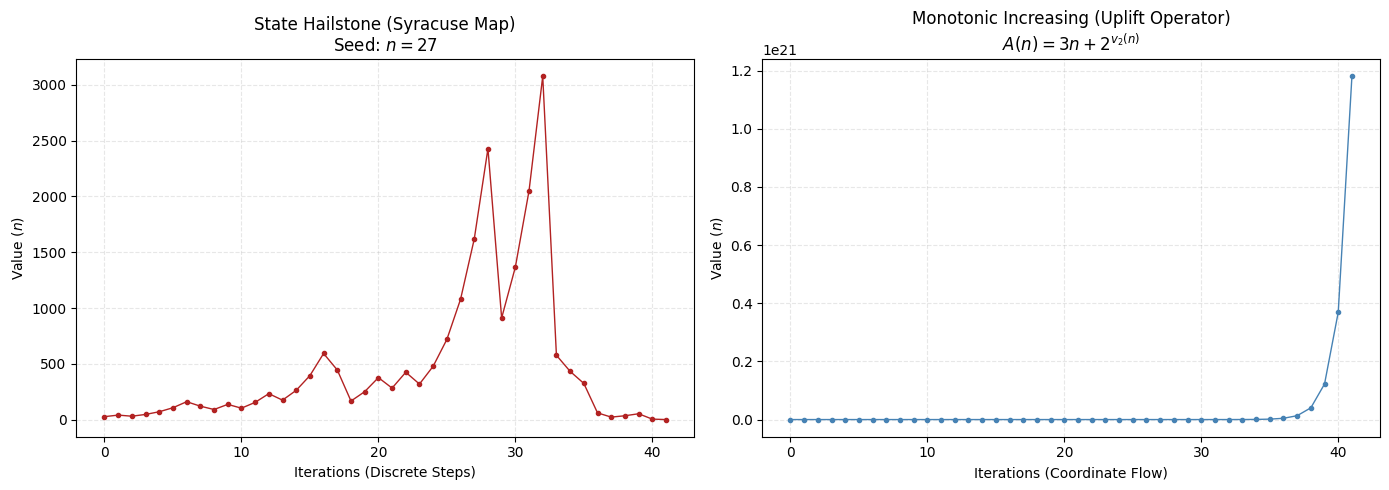

In [ ]:
import matplotlib.pyplot as plt
from typing import List

def Figure_2():
    """
    Generates the side-by-side trajectory analysis of seed n=27.
    Contrasts the non-monotonic State Hailstone with the strictly Monotonic Increasing Uplift Operator.
    (Corresponds to Figure 2 in the manuscript, discussed in Section 9 / Conclusion).
    """
    seed = 27
    syracuse_flow: List[int] = [seed]
    uplift_flow: List[int] = [seed]

    current_s = seed
    current_u = seed

    # Generate the standard Collatz Syracuse flow (Left Plot)
    while current_s > 1:
        if current_s % 2 == 0:
            current_s //= 2
        else:
            current_s = 3 * current_s + 1
            # Strip the 2-adic valuation to mimic T_syr
            while current_s % 2 == 0:
                current_s //= 2
        syracuse_flow.append(current_s)

    # Generate the Monotonic Increasing flow (Right Plot)
    for _ in range(len(syracuse_flow) - 1):
        # A(n) = 3n + 2^{v_2(n)} (See Eq. 1)
        v2 = (current_u & -current_u).bit_length() - 1
        current_u = 3 * current_u + (2**v2)
        uplift_flow.append(current_u)

    # Plot Configuration matching Section 9 / Conclusion
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left Plot: State Hailstone
    ax1.plot(syracuse_flow, color='firebrick', marker='.', linewidth=1)
    ax1.set_title("State Hailstone (Syracuse Map)\nSeed: $n=27$")
    ax1.set_xlabel("Iterations (Discrete Steps)")
    ax1.set_ylabel("Value ($n$)")
    ax1.grid(True, alpha=0.3, linestyle='--')

    # Right Plot: Monotonic Increasing Uplift Operator
    ax2.plot(uplift_flow, color='steelblue', marker='.', linewidth=1)
    ax2.set_title("Monotonic Increasing (Uplift Operator)\n$A(n) = 3n + 2^{v_2(n)}$")
    ax2.set_xlabel("Iterations (Coordinate Flow)")
    ax2.set_ylabel("Value ($n$)")
    ax2.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()

    # Save the figure as a high-res PDF for the LaTeX manuscript
    plt.savefig("Figure_2_Publication_Ready.pdf", format='pdf', bbox_inches='tight')
    print("Saved 'Figure_2_Publication_Ready.pdf' to current directory.")

    # Render the plot in the notebook
    plt.show()

if __name__ == "__main__":
    Figure_2()

In [ ]:
import pandas as pd
import time
from typing import List, Dict

def is_resolved(r: int, k: int) -> bool:
    """
    Simulates the exact trajectory of a residue class r (mod 2^k).
    Tracks the algebraic coefficients to determine if the path is mathematically
    guaranteed to drop below its initial starting value (3^A < 2^B).
    """
    n_test = r
    A = 0  # Count of Archimedean expansions (3n+1)
    B = 0  # Count of 2-adic contractions (n/2)

    # We can safely simulate as long as we haven't consumed more bits than 'k'
    while B < k:
        if n_test % 2 == 1:
            n_test = 3 * n_test + 1
            A += 1
        else:
            n_test //= 2
            B += 1
            # If the coefficient ratio drops below 1, the branch is resolved
            if 3**A < 2**B:
                return True
    return False

def Generate_Resolved_Pairs(max_k: int = 24):
    """
    Performs a Breadth-First Expansion of the Collatz tree up to a specified modulo depth.
    Generates 'resolved_pairs.csv' for the O(1) Memory Projection Sieve (See Section 7.3).
    """
    print(f"Generating Breadth-First Collatz Expansion up to depth k={max_k}...")
    start_time = time.time()

    resolved_pairs: List[Dict[str, int]] = []

    # Base Case: 1 (mod 4) is trivially resolved after two 2-adic steps
    resolved_pairs.append({'residue': 1, 'modulo': 4})

    # This leaves 3 (mod 4) as the initial indeterminate root
    unresolved: List[int] = [3]

    # Iterate through the modulo depths (k=2 represents mod 2^3 = 8)
    for k in range(2, max_k):
        next_unresolved: List[int] = []
        modulus = 2 ** (k + 1)

        for r in unresolved:
            # Branch into the two new congruence classes modulo 2^{k+1}
            branch1 = r
            branch2 = r + (2 ** k)

            # Evaluate Branch 1
            if is_resolved(branch1, k + 1):
                resolved_pairs.append({'residue': branch1, 'modulo': modulus})
            else:
                next_unresolved.append(branch1)

            # Evaluate Branch 2
            if is_resolved(branch2, k + 1):
                resolved_pairs.append({'residue': branch2, 'modulo': modulus})
            else:
                next_unresolved.append(branch2)

        unresolved = next_unresolved

        # Print progress milestones
        if (k + 1) % 4 == 0 or (k + 1) == max_k:
            # Calculate the total elimination density of the odd integer lattice
            eliminated = 1.0 - (len(unresolved) / (2 ** k))
            print(f"Depth {k+1:02d} | Modulo: 2^{k+1:<2} | Unresolved Classes: {len(unresolved):<8} | Elimination Rate: {eliminated * 100:.4f}%")

    # Save the explicitly resolved paths to a CSV for the L3 Sieve
    df = pd.DataFrame(resolved_pairs)
    df.to_csv('resolved_pairs.csv', index=False)

    end_time = time.time()
    print(f"\nDone! Generated {len(resolved_pairs):,} resolved pairs in {end_time - start_time:.2f} seconds.")
    print("Saved to 'resolved_pairs.csv'. You may now run Cell 5!")

if __name__ == "__main__":
    # max_k=24 matches the 16 MB L3 cache sizing established in the manuscript.
    # Note: Running to k=24 may take ~10-30 seconds depending on the Colab CPU.
    Generate_Resolved_Pairs(max_k=24)

Generating Breadth-First Collatz Expansion up to depth k=24...
Depth 04 | Modulo: 2^4  | Unresolved Classes: 3        | Elimination Rate: 62.5000%
Depth 08 | Modulo: 2^8  | Unresolved Classes: 19       | Elimination Rate: 85.1562%
Depth 12 | Modulo: 2^12 | Unresolved Classes: 226      | Elimination Rate: 88.9648%
Depth 16 | Modulo: 2^16 | Unresolved Classes: 2114     | Elimination Rate: 93.5486%
Depth 20 | Modulo: 2^20 | Unresolved Classes: 27328    | Elimination Rate: 94.7876%
Depth 24 | Modulo: 2^24 | Unresolved Classes: 286581   | Elimination Rate: 96.5837%

Done! Generated 81,118 resolved pairs in 3.30 seconds.
Saved to 'resolved_pairs.csv'. You may now run Cell 5!


In [ ]:
import numpy as np
import pandas as pd
import os

# Declare globals so they remain in the Jupyter namespace for Cell 6
global sieve_array
global MODULO_DEPTH

def Build_Memory_Sieve():
    """
    Implements the O(1) L3-bound Memory Projection Sieve (See Manuscript Section 7.3).
    Allocates a 16 MB boolean array and loads resolved modulo-residue pairs
    to bypass the von Neumann bottleneck.
    """
    global sieve_array
    global MODULO_DEPTH

    # Modulo depth of 2^24 aligns with 16 MB L3 cache specifications (See Section 7.3)
    MODULO_DEPTH = 2**24
    print(f"Allocating {MODULO_DEPTH / 1e6} MB for the sieve array...")

    # Initialize the boolean numpy array (False = Indeterminate, True = Resolved)
    sieve_array = np.zeros(MODULO_DEPTH, dtype=np.bool_)

    # --- Structural Bypasses (See Section 7.2) ---
    # Even numbers trivially drop below their seed on step 1 (n -> n/2 < n)
    sieve_array[0::2] = True

    # Any odd seed of the form n = 1 (mod 4) strictly drops below its initial value.
    sieve_array[1::4] = True

    # --- Pre-computed Tree Expansions ---
    # Load dynamically generated bounds if the csv is present in the repository
    if os.path.exists('resolved_pairs.csv'):
        print("Loading 'resolved_pairs.csv' and populating sieve...")
        df = pd.read_csv('resolved_pairs.csv')
        for _, row in df.iterrows():
            # Apply the modulo/residue rules from the Breadth-First Expansion
            sieve_array[row['residue']::row['modulo']] = True
    else:
        print("No 'resolved_pairs.csv' found. Proceeding with baseline structural bypasses...")
        # Fallback higher-order residues explicitly mentioned in Section 7.3
        sieve_array[3::16] = True
        sieve_array[11::16] = True

    elimination_rate = (np.sum(sieve_array) / MODULO_DEPTH) * 100
    print(f"Sieve Built! Elimination Rate: {elimination_rate:.4f}%")

if __name__ == "__main__":
    Build_Memory_Sieve()

Allocating 16.777216 MB for the sieve array...
Loading 'resolved_pairs.csv' and populating sieve...
Sieve Built! Elimination Rate: 98.2918%


In [11]:
from numba import njit
import time
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
import multiprocessing

def Cell_6_Run_Sweep():
    """
    Implements the JIT-compiled 2-adic extraction loop with uint64 overflow protection.
    Executes the continuous verification sweep up to 2^45 safely chunked via ThreadPoolExecutor.
    REQUIRES CELL 5 TO BE RUN FIRST.
    """

    if 'sieve_array' not in globals() or 'MODULO_DEPTH' not in globals():
        print("ERROR: sieve_array not found. Please run Cell 5 first!")
        return

    # We drop parallel=True, but keep nogil=True so Python can freely multi-thread it
    @njit(nogil=True)
    def verification_chunk(start: int, end: int, sieve: np.ndarray, mod_depth: int):
        # We explicitly enforce Unsigned 64-bit ints to prevent trillion-scale overflows
        max_peak = np.uint64(0)
        peak_seed = np.uint64(0)
        longest_path = 0
        path_seed = np.uint64(0)

        for n in range(start, end):
            if sieve[n % mod_depth]:
                continue

            # Cast current state to uint64
            current = np.uint64(n)
            steps = 0
            local_peak = current

            while current >= np.uint64(n):
                if current % np.uint64(2) == 0:
                    current >>= np.uint64(1)
                else:
                    current = np.uint64(3) * current + np.uint64(1)
                    if current > local_peak:
                        local_peak = current
                steps += 1

            if local_peak > max_peak:
                max_peak = local_peak
                peak_seed = np.uint64(n)
            if steps > longest_path:
                longest_path = steps
                path_seed = np.uint64(n)

        return max_peak, peak_seed, longest_path, path_seed

    SEARCH_BOUND = 2**45
    # Chunk the 35 trillion space into 1-Billion integer blocks to protect the thread scheduler
    CHUNK_SIZE = 1_000_000_000

    num_cores = multiprocessing.cpu_count()
    print(f"Initiating parallel verification up to {SEARCH_BOUND:,}...")
    print(f"Distributing 1-Billion integer chunks across {num_cores} physical CPU cores...\n")

    start_time = time.time()

    global_max_peak = np.uint64(0)
    global_peak_seed = np.uint64(0)
    global_longest_path = 0
    global_path_seed = np.uint64(0)

    # Python securely handles the 64-bit thread distribution
    with ThreadPoolExecutor(max_workers=num_cores) as executor:
        futures = []
        for chunk_start in range(3, SEARCH_BOUND, CHUNK_SIZE):
            chunk_end = min(chunk_start + CHUNK_SIZE, SEARCH_BOUND)
            futures.append(executor.submit(verification_chunk, chunk_start, chunk_end, sieve_array, MODULO_DEPTH))

        chunks_completed = 0
        total_chunks = len(futures)

        for future in as_completed(futures):
            max_peak, peak_seed, longest_path, path_seed = future.result()

            # Re-integrate the chunk bounds
            if max_peak > global_max_peak:
                global_max_peak, global_peak_seed = max_peak, peak_seed
            if longest_path > global_longest_path:
                global_longest_path, global_path_seed = longest_path, path_seed

            chunks_completed += 1
            if chunks_completed % 500 == 0: # Print status update occasionally
                print(f"Progress: {chunks_completed:,} / {total_chunks:,} chunks analyzed...")

    end_time = time.time()

    hours, rem = divmod(end_time - start_time, 3600)
    minutes, seconds = divmod(rem, 60)

    print("\n================ VERIFICATION COMPLETE ================")
    print(f"Search Space:        Up to {SEARCH_BOUND:,}")
    print(f"Total Execution Time: {int(hours)}h {int(minutes)}m {seconds:.2f}s")
    print("-" * 55)
    print(f"MAX PEAK ALTITUDE:   {global_max_peak:,}")
    print(f"PEAK SEED:           {global_peak_seed:,}")
    print("-" * 55)
    print(f"LONGEST PATH (Steps):{global_longest_path}")
    print(f"PATH SEED:           {global_path_seed:,}")
    print("=======================================================")

if __name__ == "__main__":
    Cell_6_Run_Sweep()

Initiating parallel verification up to 35,184,372,088,832...
Distributing 1-Billion integer chunks across 8 physical CPU cores...

Progress: 500 / 35,185 chunks analyzed...
Progress: 1,000 / 35,185 chunks analyzed...
Progress: 1,500 / 35,185 chunks analyzed...
Progress: 2,000 / 35,185 chunks analyzed...
Progress: 2,500 / 35,185 chunks analyzed...
Progress: 3,000 / 35,185 chunks analyzed...
Progress: 3,500 / 35,185 chunks analyzed...
Progress: 4,000 / 35,185 chunks analyzed...
Progress: 4,500 / 35,185 chunks analyzed...
Progress: 5,000 / 35,185 chunks analyzed...
Progress: 5,500 / 35,185 chunks analyzed...
Progress: 6,000 / 35,185 chunks analyzed...
Progress: 6,500 / 35,185 chunks analyzed...
Progress: 7,000 / 35,185 chunks analyzed...
Progress: 7,500 / 35,185 chunks analyzed...
Progress: 8,000 / 35,185 chunks analyzed...
Progress: 8,500 / 35,185 chunks analyzed...
Progress: 9,000 / 35,185 chunks analyzed...
Progress: 9,500 / 35,185 chunks analyzed...
Progress: 10,000 / 35,185 chunks an